- Procedencia de los viajeros por años del 2015 al 2019

In [5]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [9]:
df_anual = pd.read_csv('../../Data/INE/clean_data_procedencia_07_04_2026.csv')

In [10]:
print(df_anual.columns)

Index(['tipo', 'origen', 'pais', 'periodo', 'total', 'level', 'year', 'month',
       'date', 'pais_final'],
      dtype='object')


In [11]:
excluir = [
    "No residentes en España",
    "Unión Europea 27 (sin España)",
    "Países africanos",
    "Resto del Mundo", "Resto de la U.E.", 
]

top_n = 10

# 1. Filtrar
df_filtrado = df_anual.loc[~df_anual["pais"].isin(excluir)]

# 2. AGRUPAR (esto es lo que te faltaba)
df_agregado = (
    df_filtrado
    .groupby(["year", "pais"], as_index=False)["total"]
    .sum()
)

# 3. Ordenar + TOP N
procedencia_limpia = (
    df_agregado
    .sort_values(["year", "total"], ascending=[True, False])
    .groupby("year")
    .head(top_n)
    .reset_index(drop=True)
)

display(procedencia_limpia)

,year,pais,total
0,2015,Residentes en España,157778502.0
1,2015,Reino Unido,61081904.0
2,2015,Alemania,53442979.0
3,2015,Francia,21976744.0
4,2015,Italia,11111239.0
5,2015,Países Bajos,9360321.0
6,2015,Bélgica,7772024.0
7,2015,Suecia,5700614.0
8,2015,Suiza,4752245.0
9,2015,Rusia,4560671.0


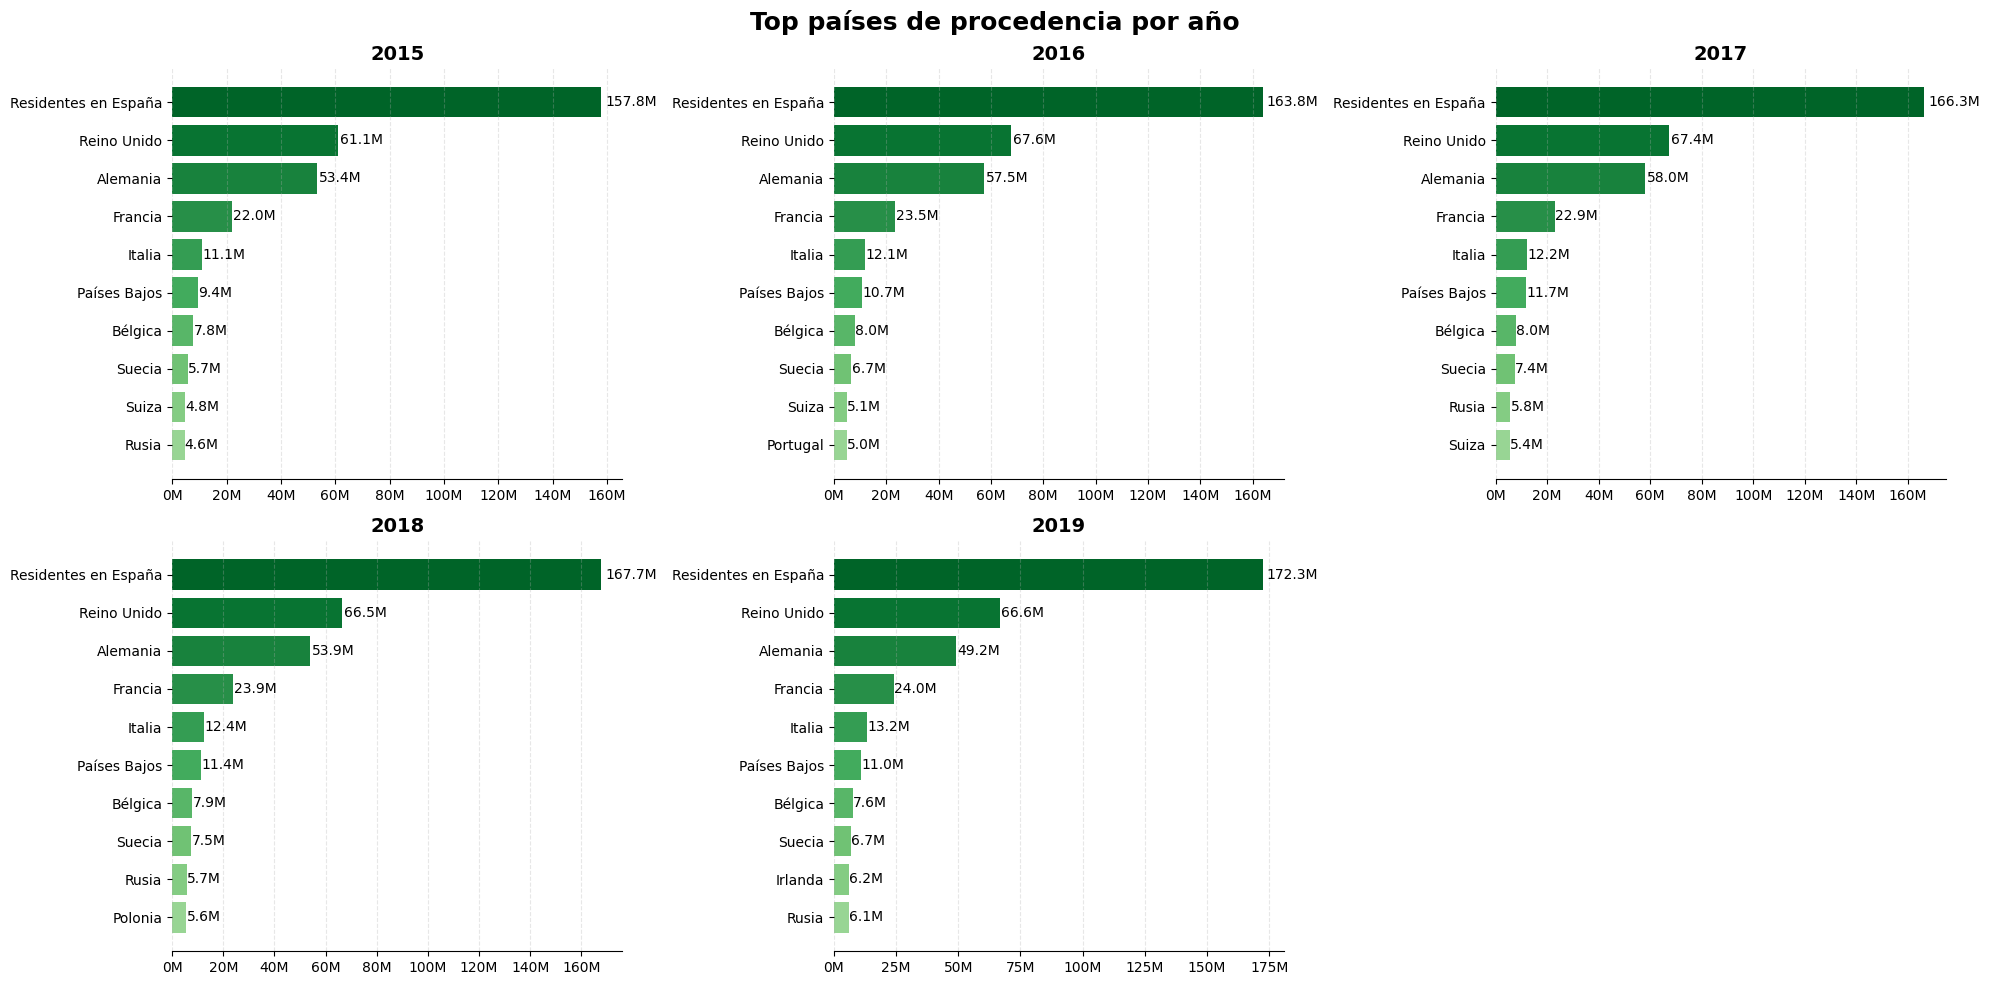

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

años = sorted(procedencia_limpia["year"].unique())

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, año in enumerate(años):
    ax = axes[i]
    
    datos = (
        procedencia_limpia[procedencia_limpia["year"] == año]
        .sort_values("total", ascending=True)
    )
    
    colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(datos)))
    
    bars = ax.barh(datos["pais"], datos["total"], color=colors)
    
    for bar, val in zip(bars, datos["total"]):
        ax.text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M",
            va="center",
            fontsize=10
        )
    
    ax.set_title(f"{año}", fontsize=14, fontweight="bold")
    
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
    )
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(axis="x", linestyle="--", alpha=0.3)

# Eliminar subplot vacío (el 6º)
fig.delaxes(axes[-1])

fig.suptitle(
    "Top países de procedencia por año",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("top_paises_grid.png", dpi=200, bbox_inches="tight")
plt.show()

In [14]:
df_ccaa_raw = pd.read_csv("../../Data/INE/clean_viajeros_07_04_2026.csv")


In [15]:
df = df_ccaa_raw.copy()

df["pais_origen"] = df["pais_origen"].str.strip().str.lower()
df["ccaa"] = df["ccaa"].str.strip()

In [16]:
excluir = [
    "no residentes en españa",
    "unión europea 27 (sin españa)",
    "países africanos",
    "resto del Mundo", "Resto de la U.E."
]

df_filtrado = df.loc[~df["pais_origen"].isin(excluir)]

In [17]:
df_ccaa = (
    df_filtrado
    .groupby(["ccaa", "pais_origen"], as_index=False)["qty_viajeros"]
    .sum()
)

In [18]:
top_n = 10

df_top = (
    df_ccaa
    .sort_values(["ccaa", "qty_viajeros"], ascending=[True, False])
    .groupby("ccaa")
    .head(top_n)
    .reset_index(drop=True)
)

In [19]:
print(df["ccaa"].unique())

['Andalucia' 'Islas Baleares' 'Cataluña' 'Comunidad Valenciana' 'Madrid']


In [20]:
ccaas_filtro = [
    "Andalucia",
    "Islas Baleares",
    "Cataluña",
    "Comunidad Valenciana",
    "Madrid"
]

df_top_filtrado = df_top[df_top["ccaa"].isin(ccaas_filtro)]

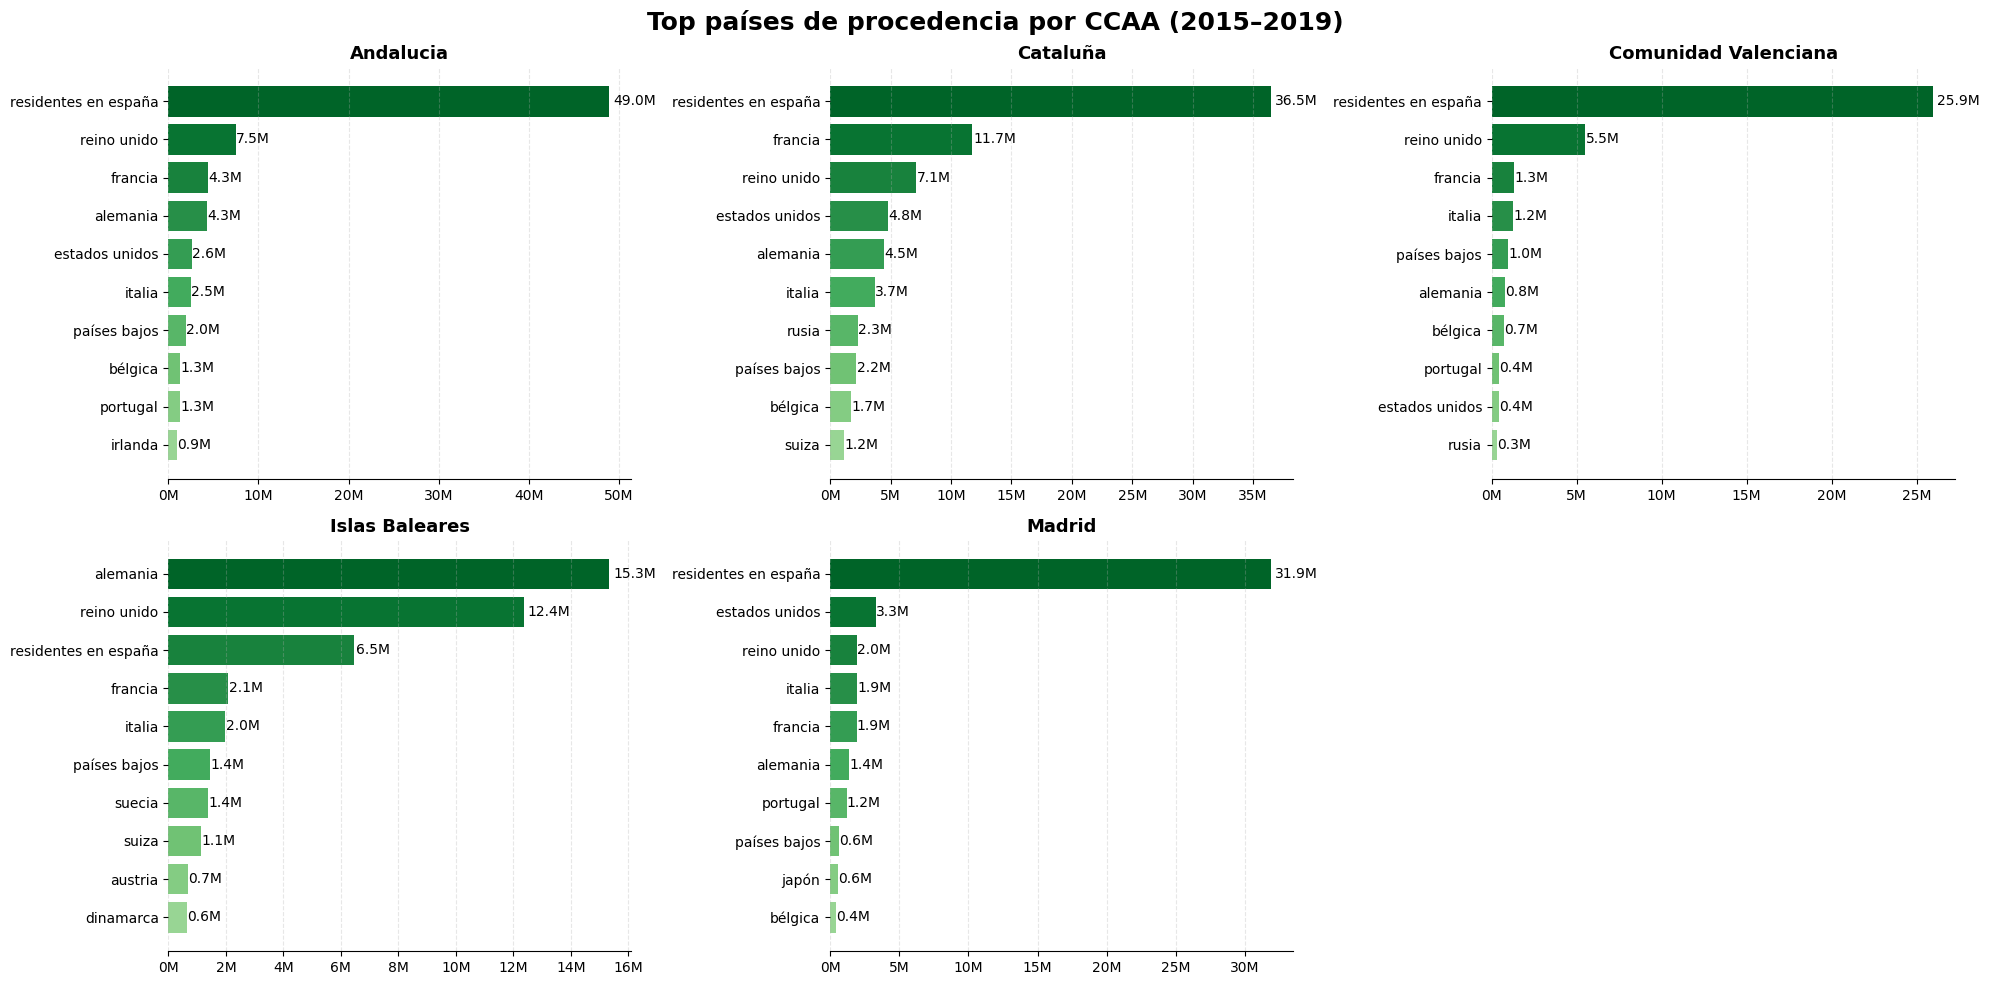

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

ccaas = sorted(df_top_filtrado["ccaa"].unique())

n_cols = 3
n_rows = -(-len(ccaas) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, ccaa in enumerate(ccaas):
    ax = axes[i]
    
    datos = (
        df_top_filtrado[df_top_filtrado["ccaa"] == ccaa]
        .sort_values("qty_viajeros", ascending=True)
    )
    
    colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(datos)))
    
    bars = ax.barh(datos["pais_origen"], datos["qty_viajeros"], color=colors)
    
    for bar, val in zip(bars, datos["qty_viajeros"]):
        ax.text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M",
            va="center",
            fontsize=10
        )
    
    ax.set_title(ccaa, fontsize=13, fontweight="bold")
    
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
    )
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    ax.grid(axis="x", linestyle="--", alpha=0.3)

# eliminar vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Top países de procedencia por CCAA (2015–2019)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("top_paises_ccaa.png", dpi=200, bbox_inches="tight")
plt.show()

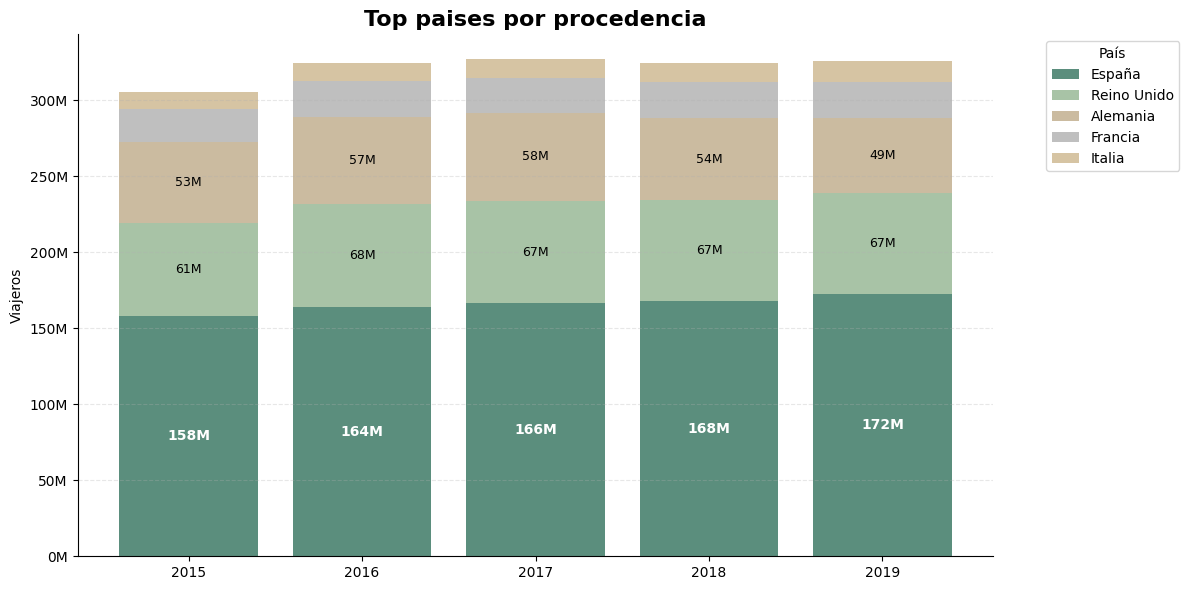

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 1. SEPARAR ESPAÑA ───────────────────────────────────────

df = procedencia_limpia.copy()

df["tipo"] = df["pais"].apply(
    lambda x: "España" if x == "Residentes en España" else "Internacional"
)

# ── 2. TOP 4 INTERNACIONAL ─────────────────────────────────

top_int = (
    df[df["tipo"] == "Internacional"]
    .groupby("pais")["total"]
    .sum()
    .sort_values(ascending=False)
    .head(4)
    .index
)

df_int = df[
    (df["tipo"] == "Internacional") &
    (df["pais"].isin(top_int))
]

# ── 3. DATOS ──────────────────────────────────────────────

pivot_int = df_int.pivot(index="year", columns="pais", values="total")

esp = (
    df[df["tipo"] == "España"]
    .groupby("year")["total"]
    .sum()
)

# ordenar internacionales por último año
orden = pivot_int.loc[pivot_int.index.max()].sort_values(ascending=False).index
pivot_int = pivot_int[orden]

# ── 4. COLORES ────────────────────────────────────────────

color_esp = "#5B8E7D"  # verde fuerte (España)

colors_int = ["#A8C3A6", "#CBBBA0", "#BFBFBF", "#D6C4A3"]

# ── 5. PLOT ───────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12,6))

# España (base)
bars_esp = ax.bar(
    esp.index,
    esp.values,
    color=color_esp,
    label="España"
)

# Internacional stacked encima
bottom = esp.copy()

bars_dict = {}

for i, col in enumerate(pivot_int.columns):
    bars = ax.bar(
        pivot_int.index,
        pivot_int[col],
        bottom=bottom,
        color=colors_int[i],
        label=col
    )
    bars_dict[col] = (bars, bottom.copy())
    bottom += pivot_int[col]

# ── 6. ETIQUETAS ──────────────────────────────────────────

# España (centro del bloque)
for rect, val in zip(bars_esp, esp.values):
    ax.text(
        rect.get_x() + rect.get_width()/2,
        val/2,
        f"{val/1e6:.0f}M",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

# Internacional (solo top 2 para no saturar)
for col in pivot_int.columns[:2]:
    bars, bottoms = bars_dict[col]
    for rect, bottom_val in zip(bars, bottoms):
        h = rect.get_height()
        if h > 5e6:
            ax.text(
                rect.get_x() + rect.get_width()/2,
                bottom_val + h/2,
                f"{h/1e6:.0f}M",
                ha="center",
                va="center",
                fontsize=9
            )

# ── 7. FORMATO ───────────────────────────────────────────

ax.set_title("Top paises por procedencia",
             fontsize=16, fontweight="bold")

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
)

ax.set_xlabel("")
ax.set_ylabel("Viajeros")

ax.legend(title="País", bbox_to_anchor=(1.05, 1), loc="upper left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("espana_vs_internacional.png", dpi=200, bbox_inches="tight")
plt.show()

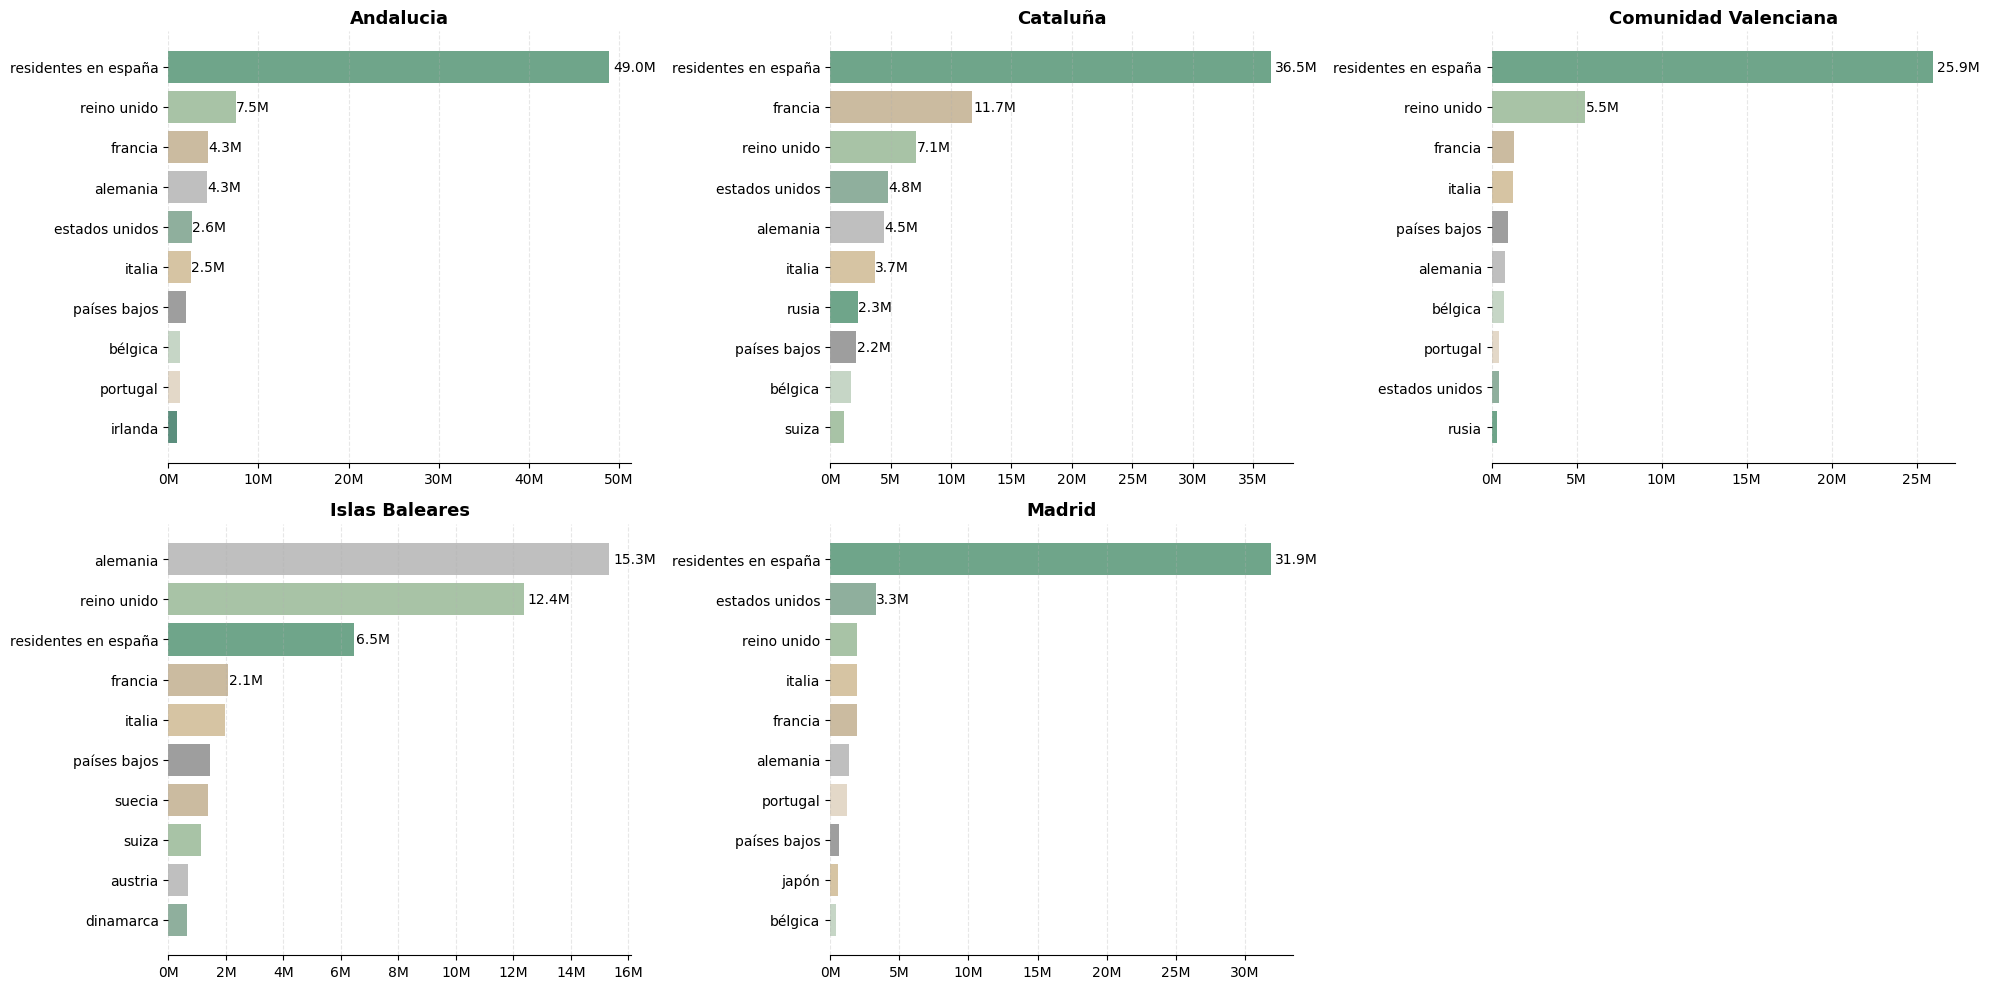

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ccaas = sorted(df_top_filtrado["ccaa"].unique())

n_cols = 3
n_rows = -(-len(ccaas) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

# ── PALETA FIJA (clave) ─────────────────────────────────────

palette = [
    "#6FA58A",  # verde principal
    "#A8C3A6",  # verde claro
    "#CBBBA0",  # beige
    "#BFBFBF",  # gris
    "#8FAF9D",
    "#D6C4A3",
    "#9E9E9E",
    "#C6D6C6",
    "#E3D8C8",
    "#5B8E7D"
]

# mapa país → color (consistente en todos los gráficos)
paises_unicos = df_top_filtrado["pais_origen"].unique()
color_map = {
    pais: palette[i % len(palette)]
    for i, pais in enumerate(paises_unicos)
}

# ── PLOT ───────────────────────────────────────────────────

for i, ccaa in enumerate(ccaas):
    ax = axes[i]
    
    datos = (
        df_top_filtrado[df_top_filtrado["ccaa"] == ccaa]
        .sort_values("qty_viajeros", ascending=True)
    )
    
    colors = [color_map[p] for p in datos["pais_origen"]]
    
    bars = ax.barh(
        datos["pais_origen"],
        datos["qty_viajeros"],
        color=colors
    )
    
    # etiquetas
    for bar, val in zip(bars, datos["qty_viajeros"]):
        if val > 2e6:  # evita ruido en valores pequeños
            ax.text(
                bar.get_width() * 1.01,
                bar.get_y() + bar.get_height()/2,
                f"{val/1e6:.1f}M",
                va="center",
                fontsize=10
            )
    
    ax.set_title(ccaa, fontsize=13, fontweight="bold")
    
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
    )
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    ax.grid(axis="x", linestyle="--", alpha=0.3)

# eliminar vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)



plt.tight_layout()
plt.savefig("top_paises_ccaa_clean.png", dpi=200, bbox_inches="tight")
plt.show()

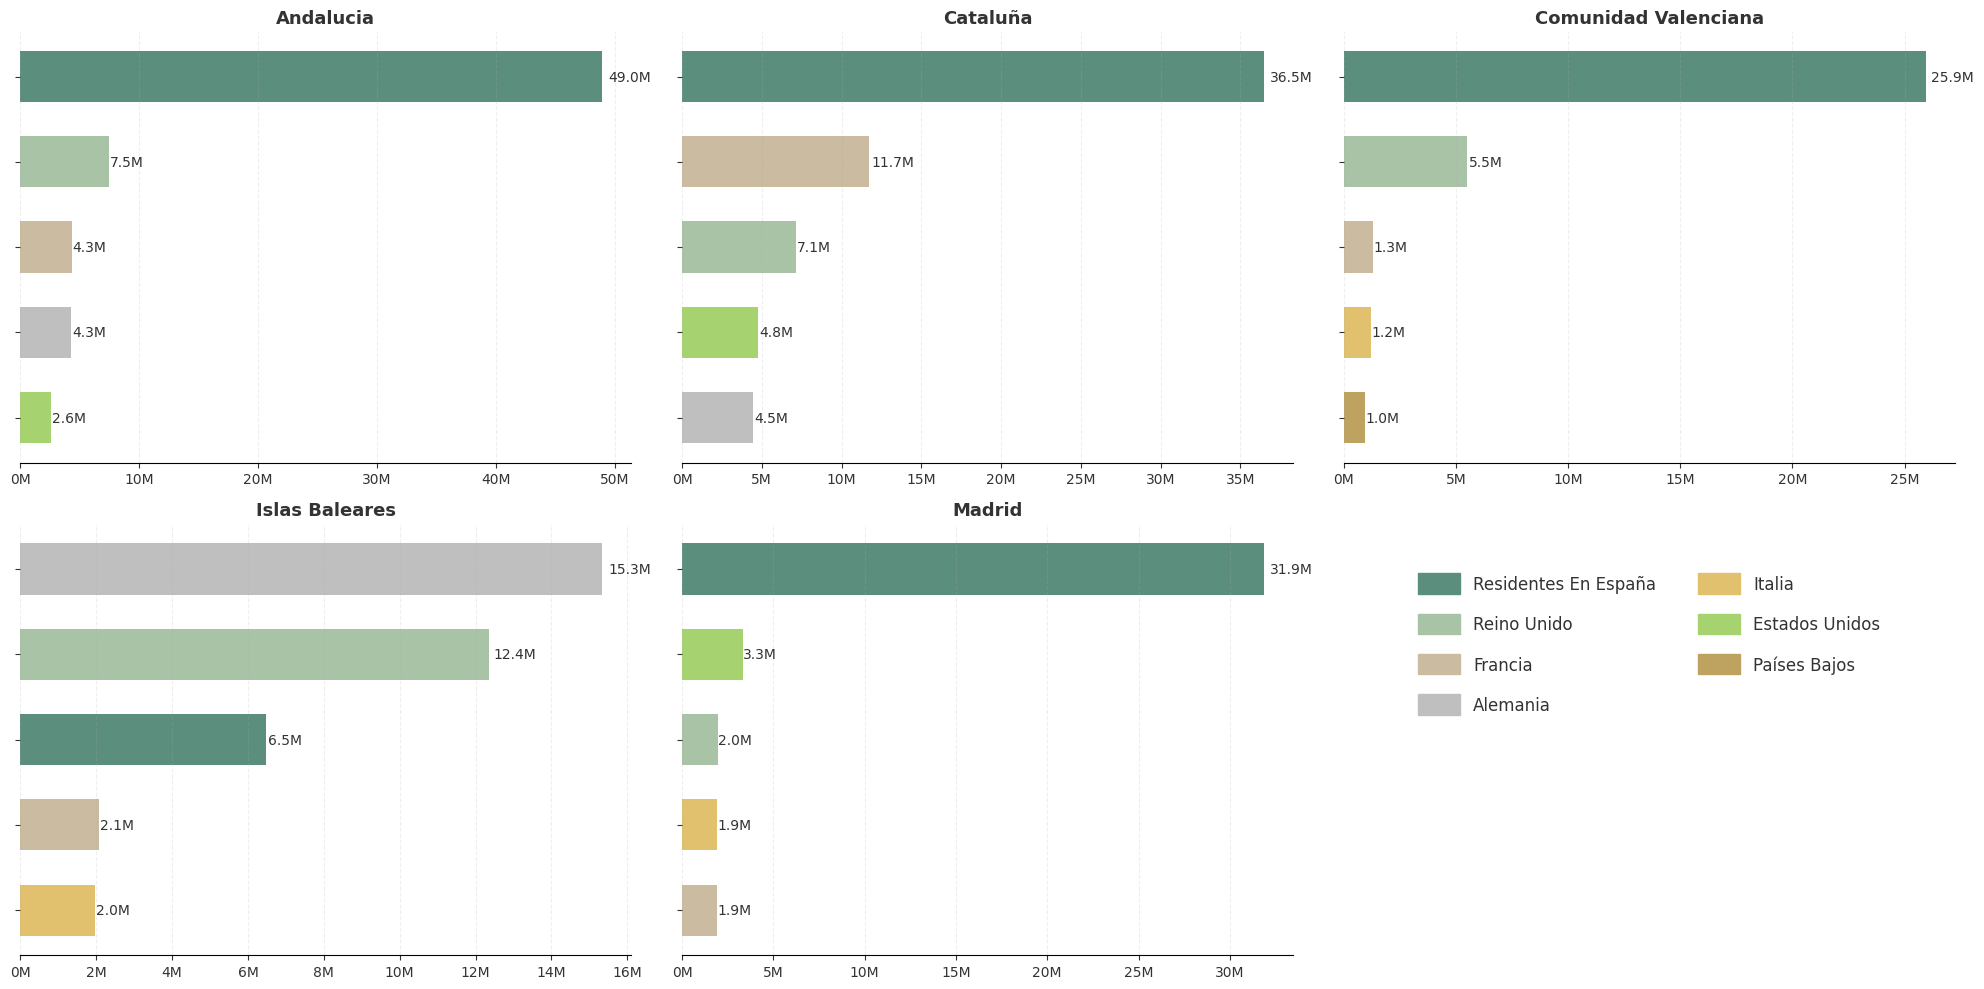

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ccaas = sorted(df_top_filtrado["ccaa"].unique())

n_cols = 3
n_rows = -(-len(ccaas) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

# ── COLORES FIJOS POR PAÍS  ────────────────────────

color_map = {
    "residentes en españa": "#5B8E7D",  # verde fuerte
    "reino unido": "#A8C3A6",
    "francia": "#CBBBA0",
    "alemania": "#BFBFBF",
    "italia": "#E1C16E",  # 👉 amarillo/beige diferenciado
    "estados unidos": "#A6D36F",
    "países bajos": "#BEA360"
}

# ── ESTILO ──────────────────────────────────────────────

plt.rcParams.update({
    "font.size": 10,
    "text.color": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333"
})

# ── PLOT ───────────────────────────────────────────────

for i, ccaa in enumerate(ccaas):
    ax = axes[i]
    
    datos = (
        df_top_filtrado[df_top_filtrado["ccaa"] == ccaa]
        .sort_values("qty_viajeros", ascending=False)
        .head(5)
        .sort_values("qty_viajeros", ascending=True)
    )
    
    colors = [color_map.get(p, "#CCCCCC") for p in datos["pais_origen"]]
    
    bars = ax.barh(
        datos["pais_origen"],
        datos["qty_viajeros"],
        color=colors,
        height=0.6
    )
    
    # etiquetas valores
    for bar, val in zip(bars, datos["qty_viajeros"]):
        ax.text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M",
            va="center",
            fontsize=10
        )
    
    ax.set_title(ccaa, fontsize=13, fontweight="bold")
    
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
    )
    
    # ❌ quitar nombres eje Y
    ax.set_yticklabels([])
    ax.set_ylabel("")
    
    # limpieza
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    ax.grid(axis="x", linestyle="--", alpha=0.2)
    ax.set_facecolor("none")

# eliminar vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# ── LEYENDA GLOBAL ───────────────────────────────────────

handles = [
    plt.Rectangle((0,0),1,1,color=color_map[k])
    for k in color_map
]

labels = [k.title() for k in color_map]

fig.legend(
    handles,
    labels,
    loc="center right",              # 👉 más centrado en el espacio vacío
    bbox_to_anchor=(0.95, 0.35),     # 👉 ajusta vertical si quieres subir/bajar
    ncol=2,
    frameon=False,
    fontsize=12,                     # 👉 texto más grande
    handlelength=2.5,                # 👉 tamaño rectángulos
    handleheight=1.5,
    labelspacing=1.2,                # 👉 espacio entre filas
    columnspacing=2.5                # 👉 separación columnas
)

fig.patch.set_alpha(0)

plt.tight_layout()

plt.savefig(
    "top5_ccaa_final_clean.png",
    dpi=200,
    bbox_inches="tight",
    transparent=True
)

plt.show()

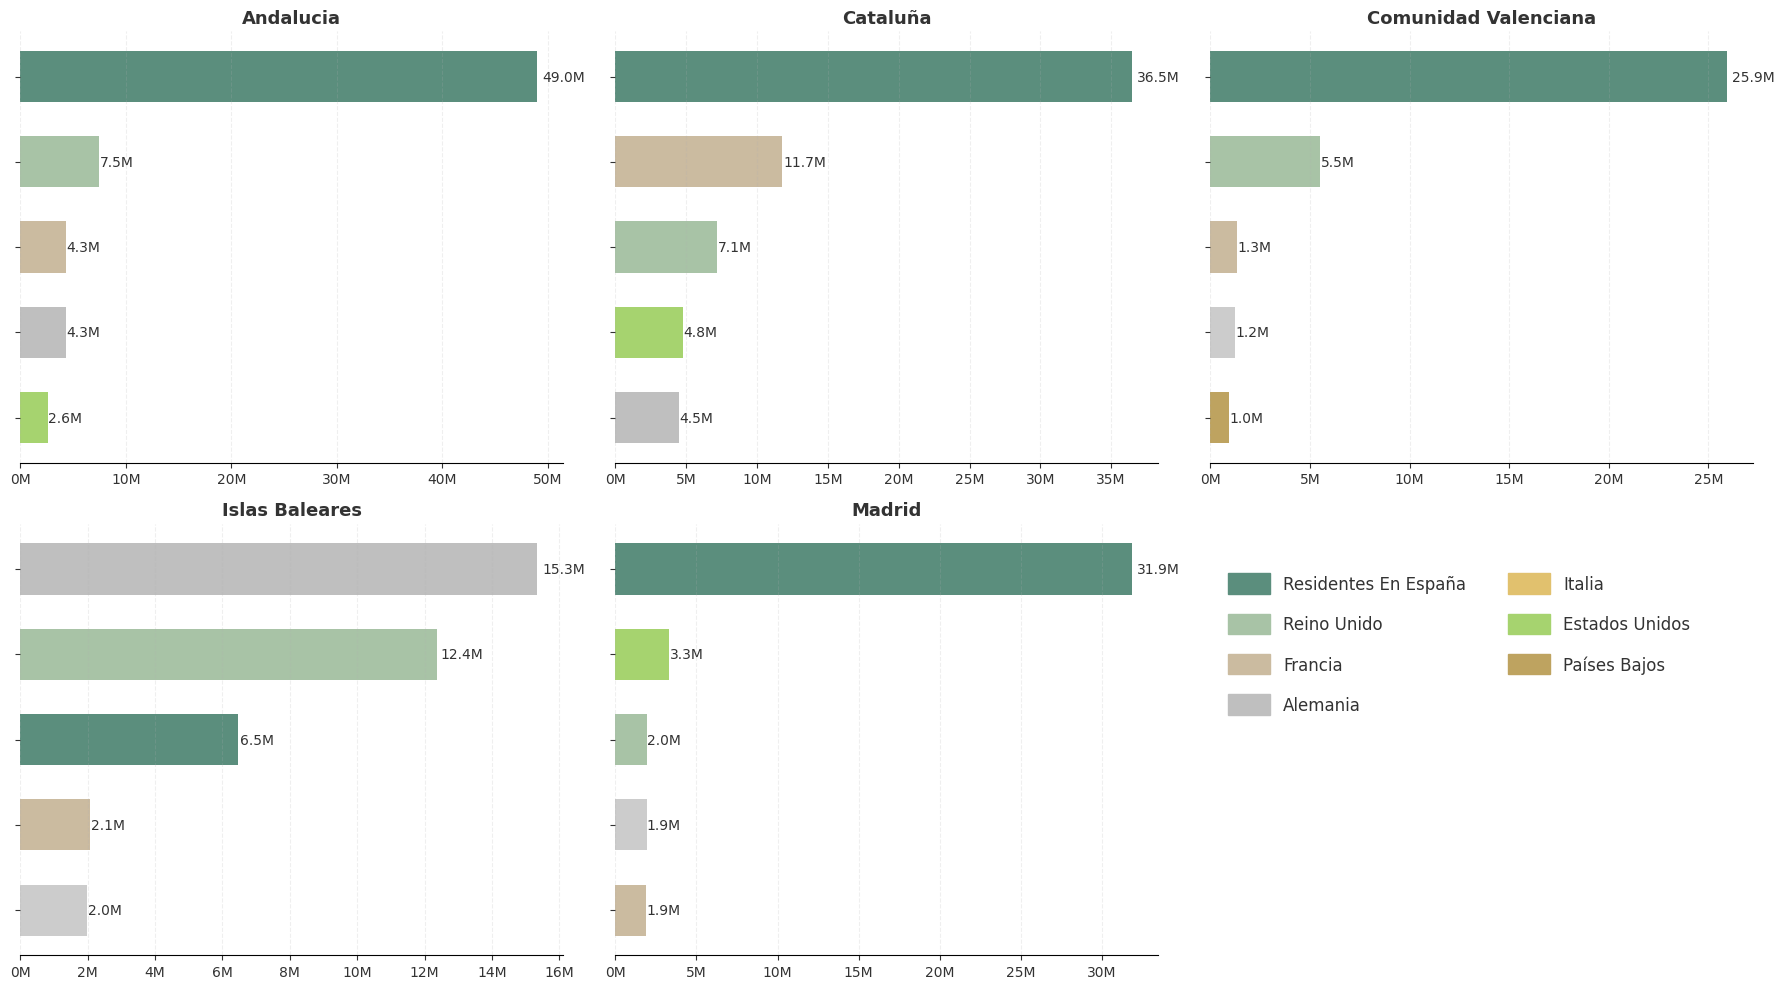

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 1. FILTRAR AÑOS ─────────────────────────────────────
df_filtrado = df[
    (df["year"] >= 2015) & (df["year"] <= 2019)
]

# ── 2. AGRUPAR (SUMA REAL) ──────────────────────────────
df_agg = (
    df_filtrado
    .groupby(["ccaa", "pais_origen"], as_index=False)["qty_viajeros"]
    .sum()
)

# ── 3. TOP 5 POR CCAA (CORREGIDO) ──────────────────────
df_top_filtrado = (
    df_agg
    .sort_values(["ccaa", "qty_viajeros"], ascending=[True, False])
    .groupby("ccaa")
    .head(5)
)

# ── COLORES FIJOS POR PAÍS ─────────────────────────────
color_map = {
    "Residentes en España": "#5B8E7D",
    "Reino Unido": "#A8C3A6",
    "Francia": "#CBBBA0",
    "Alemania": "#BFBFBF",
    "italia": "#E1C16E",
    "Estados Unidos": "#A6D36F",
    "Países Bajos": "#BEA360"
}

# ── ESTILO ─────────────────────────────────────────────
plt.rcParams.update({
    "font.size": 10,
    "text.color": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333"
})

# ── PREPARAR GRID ──────────────────────────────────────
ccaas = df_top_filtrado["ccaa"].unique()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# ── PLOT ───────────────────────────────────────────────
for i, ccaa in enumerate(ccaas):
    ax = axes[i]
    
    datos = (
        df_top_filtrado[df_top_filtrado["ccaa"] == ccaa]
        .sort_values("qty_viajeros", ascending=True)
    )
    
    colors = [color_map.get(p, "#CCCCCC") for p in datos["pais_origen"]]
    
    bars = ax.barh(
        datos["pais_origen"],
        datos["qty_viajeros"],
        color=colors,
        height=0.6
    )
    
    # etiquetas
    for bar, val in zip(bars, datos["qty_viajeros"]):
        ax.text(
            bar.get_width() * 1.01,
            bar.get_y() + bar.get_height()/2,
            f"{val/1e6:.1f}M",
            va="center",
            fontsize=10
        )
    
    ax.set_title(ccaa, fontsize=13, fontweight="bold")
    
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
    )
    
    # quitar eje Y
    ax.set_yticklabels([])
    ax.set_ylabel("")
    
    # limpieza visual
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    
    ax.grid(axis="x", linestyle="--", alpha=0.2)
    ax.set_facecolor("none")

# ── ELIMINAR EJES VACÍOS ───────────────────────────────
for j in range(len(ccaas), len(axes)):
    axes[j].set_visible(False)

# ── LEYENDA GLOBAL ─────────────────────────────────────
handles = [
    plt.Rectangle((0,0),1,1,color=color_map[k])
    for k in color_map
]

labels = [k.title() for k in color_map]

fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(0.95, 0.35),
    ncol=2,
    frameon=False,
    fontsize=12,
    handlelength=2.5,
    handleheight=1.5,
    labelspacing=1.2,
    columnspacing=2.5
)

# ── FINAL ──────────────────────────────────────────────
fig.patch.set_alpha(0)

plt.tight_layout()

plt.savefig(
    "top5_ccaa_final_clean.png",
    dpi=200,
    bbox_inches="tight",
    transparent=True
)

plt.show()

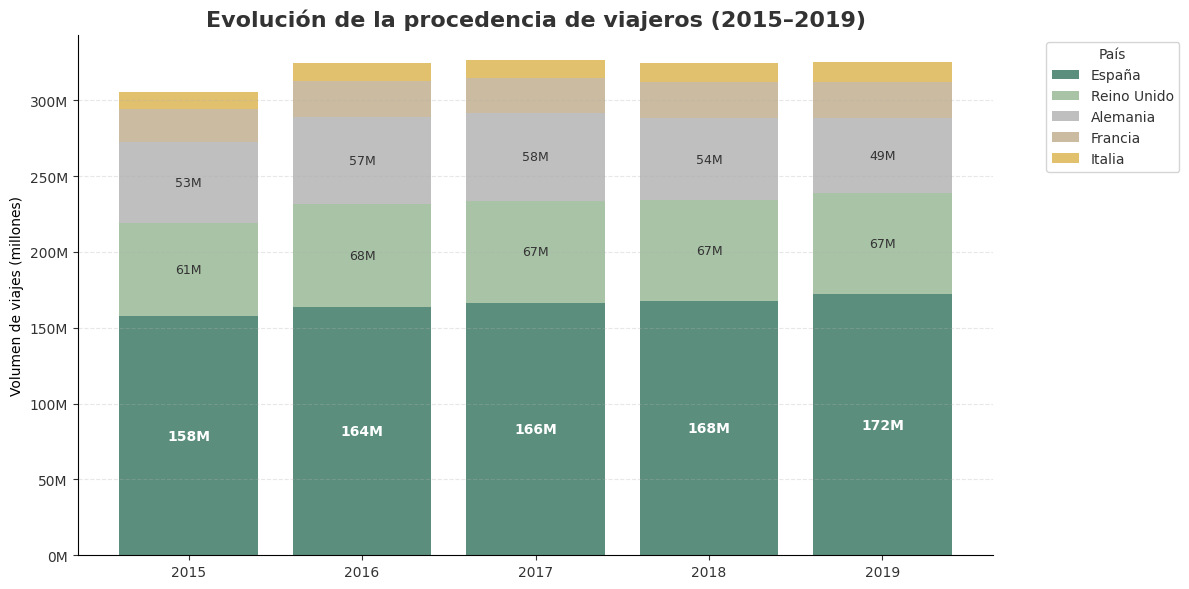

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 1. SEPARAR ESPAÑA ───────────────────────────────────────

df = procedencia_limpia.copy()

df["tipo"] = df["pais"].apply(
    lambda x: "España" if x == "Residentes en España" else "Internacional"
)

# ── 2. TOP 4 INTERNACIONAL ─────────────────────────────────

top_int = (
    df[df["tipo"] == "Internacional"]
    .groupby("pais")["total"]
    .sum()
    .sort_values(ascending=False)
    .head(4)
    .index
)

df_int = df[
    (df["tipo"] == "Internacional") &
    (df["pais"].isin(top_int))
]

# ── 3. DATOS ──────────────────────────────────────────────

pivot_int = (
    df_int
    .pivot(index="year", columns="pais", values="total")
    .fillna(0)
)

esp = (
    df[df["tipo"] == "España"]
    .groupby("year")["total"]
    .sum()
)

# ordenar internacionales por último año
orden = pivot_int.loc[pivot_int.index.max()].sort_values(ascending=False).index
pivot_int = pivot_int[orden]

# ── 4. COLORES (CONSISTENTES CON TU SISTEMA) ──────────────

color_map_stack = {
    "España": "#5B8E7D",
    "Reino Unido": "#A8C3A6",
    "Francia": "#CBBBA0",
    "Alemania": "#BFBFBF",
    "Italia": "#E1C16E",
    "Estados Unidos": "#A6D36F",
    "Países Bajos": "#BEA360"
}

# colores en orden dinámico según columnas
colors_int = [color_map_stack.get(col, "#CCCCCC") for col in pivot_int.columns]

# ── 5. PLOT ───────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12,6))

# España (base)
bars_esp = ax.bar(
    esp.index,
    esp.values,
    color=color_map_stack["España"],
    label="España"
)

# Internacional stacked
bottom = esp.copy()
bars_dict = {}

for col, color in zip(pivot_int.columns, colors_int):
    bars = ax.bar(
        pivot_int.index,
        pivot_int[col],
        bottom=bottom,
        color=color,
        label=col
    )
    bars_dict[col] = (bars, bottom.copy())
    bottom += pivot_int[col]

# ── 6. ETIQUETAS ──────────────────────────────────────────

# España
for rect, val in zip(bars_esp, esp.values):
    ax.text(
        rect.get_x() + rect.get_width()/2,
        val/2,
        f"{val/1e6:.0f}M",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white"
    )

# Internacional (solo top 2 visibles)
for col in pivot_int.columns[:2]:
    bars, bottoms = bars_dict[col]
    for rect, bottom_val in zip(bars, bottoms):
        h = rect.get_height()
        if h > 5e6:
            ax.text(
                rect.get_x() + rect.get_width()/2,
                bottom_val + h/2,
                f"{h/1e6:.0f}M",
                ha="center",
                va="center",
                fontsize=9
            )

# ── 7. FORMATO ───────────────────────────────────────────

ax.set_title("Evolución de la procedencia de viajeros (2015–2019)",
             fontsize=16, fontweight="bold")

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
)

ax.set_xlabel("")
ax.set_ylabel("Volumen de viajes (millones)")

ax.legend(title="País", bbox_to_anchor=(1.05, 1), loc="upper left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.savefig(
    "evolucion_procedencia.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()